In [ ]:
# Step 1 Data Preprocessing
#Loading, normalizing and splitting the dataset

from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader


transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='./Assignment4ML/data', train=True, download=True, transform=transform)

train_sub, val_sub = random_split(train_dataset, [50000, 10000])

train_loader = DataLoader(train_sub, batch_size=64, shuffle=True)
val_loader = DataLoader(val_sub, batch_size=64, shuffle=False)



In [ ]:
class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()
        # Two conv layers before the first pool
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Higher filter count in the second block
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(64 * 7 * 7, 10)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

#version 1

In [31]:
#version 2
class DeepCNN2(nn.Module):
    def __init__(self):
        super(DeepCNN2, self).__init__()
        # Two conv layers before the first pool
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Higher filter count in the second block
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential (
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)
device2 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepCNN2().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [28]:
import torch.optim as optim

# 1. Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    train_loss, train_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == labels).sum().item()
    
    # --- VALIDATION ---
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()
            
    # Record metrics
    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))
    history['train_acc'].append(train_correct / len(train_sub))
    history['val_acc'].append(val_correct / len(val_sub))

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")

Epoch [1/10] | Train Loss: 0.0863 | Val Loss: 0.2725 | Val Acc: 0.9215
Epoch [2/10] | Train Loss: 0.0750 | Val Loss: 0.2967 | Val Acc: 0.9157
Epoch [3/10] | Train Loss: 0.0678 | Val Loss: 0.2967 | Val Acc: 0.9195
Epoch [4/10] | Train Loss: 0.0582 | Val Loss: 0.3046 | Val Acc: 0.9214
Epoch [5/10] | Train Loss: 0.0558 | Val Loss: 0.3416 | Val Acc: 0.9204
Epoch [6/10] | Train Loss: 0.0503 | Val Loss: 0.3525 | Val Acc: 0.9204
Epoch [7/10] | Train Loss: 0.0438 | Val Loss: 0.3785 | Val Acc: 0.9192
Epoch [8/10] | Train Loss: 0.0422 | Val Loss: 0.3668 | Val Acc: 0.9176
Epoch [9/10] | Train Loss: 0.0354 | Val Loss: 0.4143 | Val Acc: 0.9184
Epoch [10/10] | Train Loss: 0.0347 | Val Loss: 0.4253 | Val Acc: 0.9187


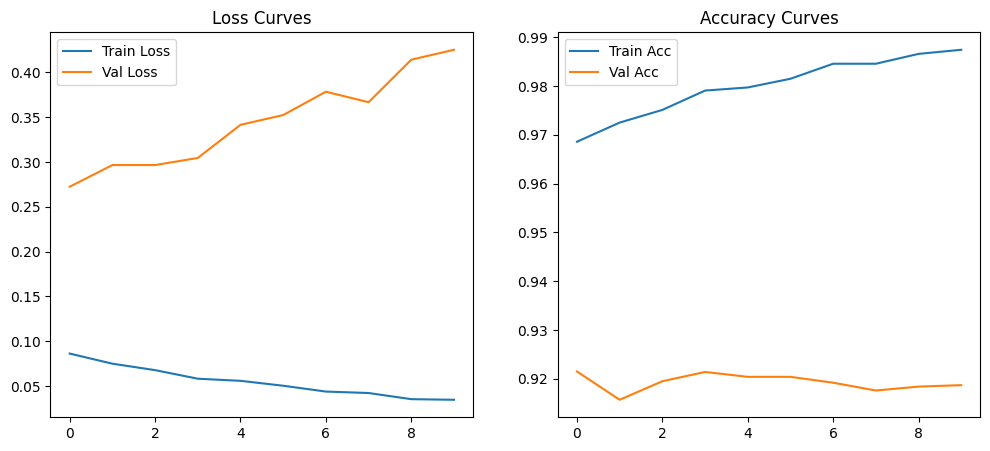

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Test Accuracy
test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [34]:
#version 2
class DeepCNN2(nn.Module):
    def __init__(self):
        super(DeepCNN2, self).__init__()
        # Two conv layers before the first pool
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        # Higher filter count in the second block
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential (
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)
device2 = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepCNN2().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [35]:
#version 2
import torch.optim as optim

# 1. Setup
device2 = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    train_loss, train_correct = 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device2), labels.to(device2)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == labels).sum().item()
    
    # --- VALIDATION ---
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_correct += (predicted == labels).sum().item()
            
    # Record metrics
    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss / len(val_loader))
    history['train_acc'].append(train_correct / len(train_sub))
    history['val_acc'].append(val_correct / len(val_sub))

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {history['train_loss'][-1]:.4f} | Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.4f}")

Epoch [1/10] | Train Loss: 0.4915 | Val Loss: 0.2871 | Val Acc: 0.8917
Epoch [2/10] | Train Loss: 0.3252 | Val Loss: 0.2622 | Val Acc: 0.9051
Epoch [3/10] | Train Loss: 0.2778 | Val Loss: 0.2386 | Val Acc: 0.9115
Epoch [4/10] | Train Loss: 0.2507 | Val Loss: 0.2390 | Val Acc: 0.9117
Epoch [5/10] | Train Loss: 0.2268 | Val Loss: 0.2253 | Val Acc: 0.9202
Epoch [6/10] | Train Loss: 0.2107 | Val Loss: 0.2201 | Val Acc: 0.9249
Epoch [7/10] | Train Loss: 0.1946 | Val Loss: 0.2146 | Val Acc: 0.9262
Epoch [8/10] | Train Loss: 0.1773 | Val Loss: 0.2097 | Val Acc: 0.9272
Epoch [9/10] | Train Loss: 0.1654 | Val Loss: 0.2124 | Val Acc: 0.9288
Epoch [10/10] | Train Loss: 0.1538 | Val Loss: 0.2210 | Val Acc: 0.9308


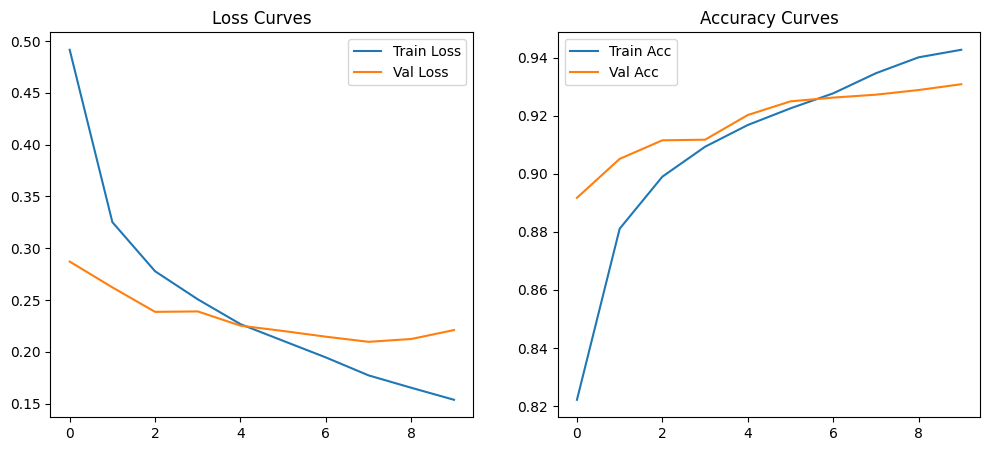

In [36]:
#version 2
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curves')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()

plt.show()


Final Test Accuracy: 0.9242


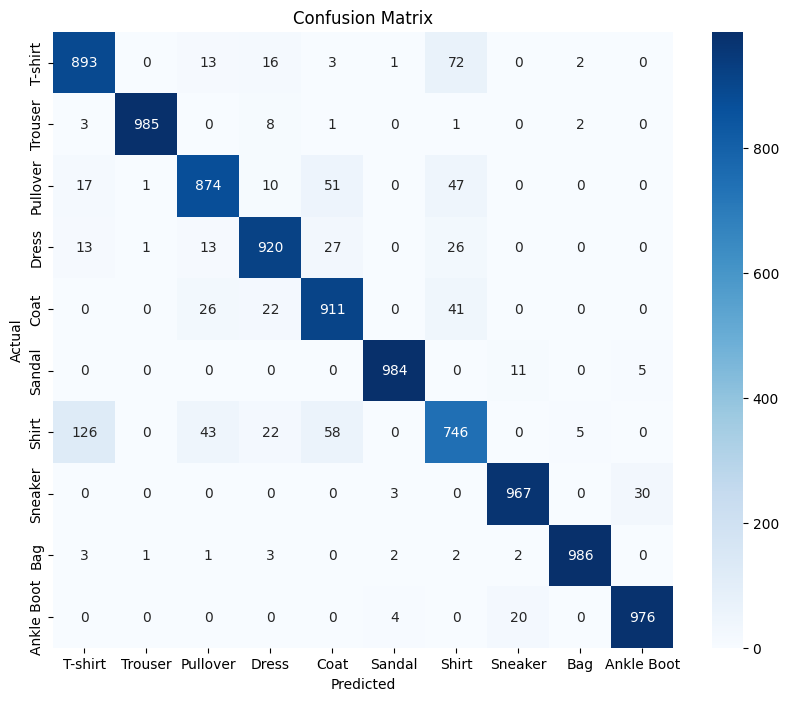

In [37]:
#version 2
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Test Accuracy
test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")

# Confusion Matrix
classes = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()